# Neural Networks 


## Activate access to Google Drive 

In [11]:
# ##### If using Google Colab -- Uncomment following lines ######

# from google.colab import drive
# drive.mount('/content/gdrive')

## Import Files and Modules

In [12]:
import json
import random
import sys

import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# from tensorflow.keras.datasets import mnist

import matplotlib.pyplot as plt


## Load MNIST Dataset

In [13]:
## Load the MNIST dataset
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)  

## Renormalize the pixels. Note the Pixels values in MNIST range from 0 to 255 (8-bit grayscale: 0 = black, 255 = white), and dividing by 255 rescales them to the [0, 1] range.
X = X / 255.0 
## Convert the labels into integers.
y = y.astype(int)

## Split the data into train (80%) and test (20%) split 
X1, X_test, y1, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X1, y1, test_size=0.2, random_state=42)

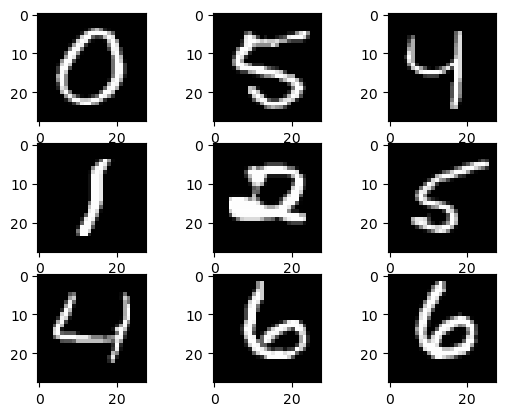

In [14]:
for i in range(9):  
    plt.subplot(330 + 1 + i)
    plt.imshow(np.reshape(X_train[i], (28,28)), cmap=plt.get_cmap('gray'))
plt.show()

## Loss function Calculator

In [28]:
class CrossEntropyCost:
    """Categorical cross-entropy, paired with softmax output."""
    @staticmethod
    def loss(a, y):
        return -np.sum(y * np.log(a + 1e-9*np.ones(np.shape(a)))) / np.shape(y)[0]
    # np.sum(np.nan_to_num(-y*np.log(a)-(1-y)*np.log(1-a)))

    @staticmethod
    def delta(a, y):
        return (a - y) / y.shape[0]      # softmax + CE shortcut


class MSECost:
    """Mean squared error, paired with softmax output here."""
    @staticmethod
    def loss(a, y):
        return np.sum((a - y)**2) / (2 * y.shape[0])

    @staticmethod
    def delta(a, y):
        return (a - y) / y.shape[0]      # assumes linear/identity output

## Neural Network module

In [52]:
class NeuralNet:

    def __init__(self, input_size = 784, ouptut_size = 10, layers=[64], lr=0.1, activation='relu', cost=CrossEntropyCost):
        """ Initialize the class:
            -- layers   : a list that contains the number of neurons in each hidden layer.
            -- lr       : Learning rate 
            -- cost     : Cost function used. 
        """
        self.layers = [input_size] + layers + [ouptut_size]
        # np.random.seed(42)
        self.num_layers = len(self.layers)
        self.activation_func = activation
        self.lr = lr
        self.cost = cost
        self.b = [np.zeros(y) for y in self.layers[1:] ]
        if activation == 'relu':
            self.W = [np.random.randn(x, y)*np.sqrt(2/x) for x, y in zip(self.layers[:-1], self.layers[1:]) ]
        else:
            self.W = [np.random.randn(x, y)*np.sqrt(2/x) for x, y in zip(self.layers[:-1], self.layers[1:]) ]    

 
    @staticmethod
    def _relu(z):
        """ The ReLU activation function"""
        return np.maximum(0, z)

    @staticmethod
    def _sigmoid(z):
        """The Sigmoid activation function."""
        return 1.0/(1.0+np.exp(-z))

    @staticmethod
    def softmax(z):
        e = np.exp(z - z.max(axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)

    @staticmethod
    def out_val(y, classes = 10):
        out = np.zeros((np.size(y), classes))
        out[np.arange(y.size), y] = 1
        return out


    def _act_deriv(self,z):
        if self.activation_func == 'relu':
            return (z > 0).astype(z.dtype)
        elif self.activation_func == 'sigmoid':
            s = 1 / (1 + np.exp(-z))
            return s * (1 - s)
        else:
            return None
        

    def forward(self, x):
        self.Zs, self.activations = [], [x]
        for i in range(self.num_layers - 1):
            z = np.dot(self.activations[i], self.W[i]) + self.b[i]     #### z = x.W + b 
            self.Zs.append(z)
            if self.activation_func == 'relu':
                self.activations.append(self._relu(z) if i < len(self.W) - 1 else self.softmax(z))    #### a_i = ReLu(z)
            elif self.activation_func == 'sigmoid':    
                self.activations.append(self._sigmoid(z) if i < len(self.W) - 1 else self.softmax(z))   #### a_i = sigmoid(z)
            else:
                print("Activation function unknown")
                None
        return self.activations

    def backpropagation(self, yb):
        dz = (self.cost).delta(self.activations[-1], yb)
        for l in range(self.num_layers - 2, -1, -1):
            dW = np.dot(np.transpose(self.activations[l]),dz)
            db = dz.sum(axis = 0)
            if l > 0:
                zs = self.Zs[l-1]
                dz = np.dot(dz, np.transpose(self.W[l]))*self._act_deriv(zs) 
            self.W[l] -= self.lr*dW
            self.b[l] -= self.lr*db

    def SGD(self, X, y, X_val=None, y_val=None, epochs=20, batch_size=64):
        Y = self.out_val(y)
        loss, accuracy = [] , []
        for epoch in range(epochs):
            idx = np.random.permutation(X.shape[0])
            Xs, Ys = X[idx], Y[idx]
            epoch_loss = 0.0
            for i in range(0, Xs.shape[0], batch_size):
                yb = Ys[i:i+batch_size]
                out = self.forward(Xs[i:i+batch_size])
                epoch_loss += self.cost.loss(out[-1], yb) * yb.shape[0]
                self.backpropagation(yb)
            epoch_loss /= X.shape[0]
            # msg = f"epoch {epoch+1}: loss {epoch_loss:.4f}"
            if X_val is not None:
                acc = (self.predict(X_val) == y_val).mean()
                # msg += f" | val acc {acc:.4f}"
                accuracy.append(acc)
            loss.append(epoch_loss)
            # print(msg)
            print(f"epoch {epoch+1}: loss {loss[-1]:.4f}", 
              f"| val acc {accuracy[-1]:.4f}" if X_val is not None else "")
        return loss, accuracy

    def predict(self, X):
        return self.forward(X)[-1].argmax(axis=1)

    


In [53]:
net = NeuralNet(input_size = 784, ouptut_size = 10, layers=[64, 64], lr=0.1, activation='relu', cost=CrossEntropyCost)
loss, accuracy = net.SGD(X_train, y_train, X_val, y_val, epochs=20)

epoch 1: loss 0.3843 | val acc 0.9343
epoch 2: loss 0.1834 | val acc 0.9513
epoch 3: loss 0.1363 | val acc 0.9575
epoch 4: loss 0.1080 | val acc 0.9649
epoch 5: loss 0.0926 | val acc 0.9646
epoch 6: loss 0.0764 | val acc 0.9688
epoch 7: loss 0.0659 | val acc 0.9646
epoch 8: loss 0.0593 | val acc 0.9709
epoch 9: loss 0.0511 | val acc 0.9700
epoch 10: loss 0.0454 | val acc 0.9729
epoch 11: loss 0.0400 | val acc 0.9710
epoch 12: loss 0.0356 | val acc 0.9693
epoch 13: loss 0.0311 | val acc 0.9739
epoch 14: loss 0.0261 | val acc 0.9727
epoch 15: loss 0.0251 | val acc 0.9735
epoch 16: loss 0.0219 | val acc 0.9736
epoch 17: loss 0.0178 | val acc 0.9747
epoch 18: loss 0.0160 | val acc 0.9717
epoch 19: loss 0.0141 | val acc 0.9751
epoch 20: loss 0.0113 | val acc 0.9752


In [54]:
# print(net.layers)
for i in range(np.size(net.layers)-1):
    print(f"{i}th layer {net.layers[i]} Neurons")
    print("Dimension of Weight matrix W :", np.shape(net.W[i]))
    print("Dimension of Bias matrix b :",np.shape(net.b[i]))
    print()
# print(np.shape(net.W))
# print(np.shape(net.b))

0th layer 784 Neurons
Dimension of Weight matrix W : (784, 64)
Dimension of Bias matrix b : (64,)

1th layer 64 Neurons
Dimension of Weight matrix W : (64, 64)
Dimension of Bias matrix b : (64,)

2th layer 64 Neurons
Dimension of Weight matrix W : (64, 10)
Dimension of Bias matrix b : (10,)



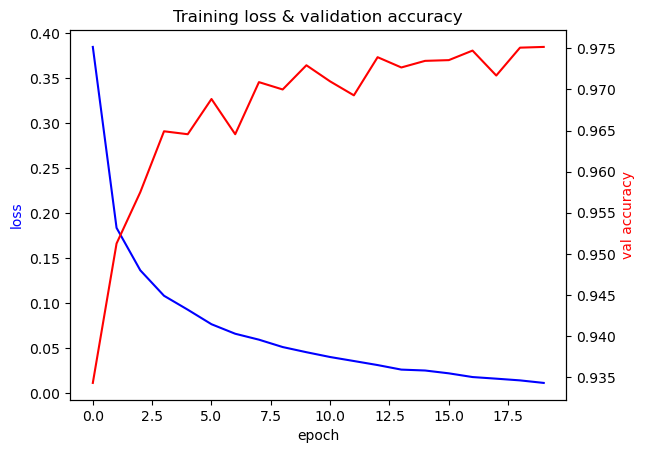

In [ ]:
# === 1. Loss / accuracy curves ===
fig, ax1 = plt.subplots()
ax1.plot(loss, 'b-', label='train loss')
ax1.set_xlabel('epoch'); ax1.set_ylabel('loss', color='b')
ax2 = ax1.twinx()
ax2.plot(accuracy, 'r-', label='Validation accuracy', fontsize = 20)
ax2.set_ylabel('val accuracy', color='r')
plt.title('Training loss & validation accuracy', fontsize = 22)
plt.show()
